In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
cars = pd.read_csv('all_car_adverts.csv')

In [3]:
# Keep rows with genuine year values
cars_clean = cars.loc[ cars.year.str[0:2].isin(['19','20']) ]

In [4]:
# Cars with missing miles don't have mileage in the specs (some have "1 mile" but that is clearly incorrect). Drop these rows.
with pd.option_context('display.max_colwidth', None):
    print(cars_clean.loc[(cars_clean.miles.isna()) & (cars_clean.car_specs.str.contains('1 mile')),['car_specs','miles']])


                                                                      car_specs  \
4375           2022 (72 reg), SUV, 1 mile, 2.9L, 510PS, Automatic, Petrol, ULEZ   
4817           2022 (72 reg), SUV, 1 mile, 2.9L, 510PS, Automatic, Petrol, ULEZ   
4921    2022 (72 reg), SUV, 1 mile, 1.5L, 160PS, Automatic, Petrol Hybrid, ULEZ   
4927    2022 (72 reg), SUV, 1 mile, 1.5L, 160PS, Automatic, Petrol Hybrid, ULEZ   
4957    2022 (72 reg), SUV, 1 mile, 1.5L, 160PS, Automatic, Petrol Hybrid, ULEZ   
...                                                                         ...   
733680   2022 (22 reg), SUV, 1 mile, 1.2L, 130PS, Manual, Petrol, 1 owner, ULEZ   
734393            2022 (22 reg), SUV, 1 mile, 1.2L, 130PS, Manual, Petrol, ULEZ   
734412   2022 (22 reg), SUV, 1 mile, 1.2L, 130PS, Manual, Petrol, 1 owner, ULEZ   
788197         2022 (22 reg), SUV, 1 mile, 1.5L, 150PS, Automatic, Petrol, ULEZ   
791479         2022 (22 reg), SUV, 1 mile, 1.5L, 150PS, Automatic, Petrol, ULEZ   

   

In [5]:
# Remove cars with missing mileage data
cars_clean = cars_clean.dropna(subset=['miles'])

In [6]:
cars_clean.loc[(cars_clean.model.isna()),['car_title','make','model']]

,car_title,make,model
6,AC Cobra,AC,NaN
7,AC Cobra,AC,NaN
5140,Alpine A110,Alpine,NaN
5154,Alpine A110,Alpine,NaN
5155,Alpine A110,Alpine,NaN
...,...,...,...
612043,REO Flying Cloud,Reo,NaN
612045,Replica Cobra,Replica,NaN
649955,Shelby Cobra,Shelby,NaN
654124,Sunbeam Alpine,Sunbeam,NaN


In [7]:
# Function to retrieve model from car title by removing the make and the space after it
def model_from_title(row):
    if pd.notnull(row.car_title) and pd.notnull(row.make):
        return row.car_title[len(row.make)+1:]
    return np.nan

# Fill in any missing model values using the car title  
cars_clean.model = cars_clean.model.fillna(cars_clean.apply(model_from_title, axis=1))

In [21]:
cars_clean.sort_values(by='car_price',ascending=False).head(20)

,Unnamed: 0,make,model,variant,car_price,car_badges,car_title,car_sub_title,car_attention_grabber,car_specs,...,num_owner,ulez,full_service,part_service,part_warranty,full_dealership,first_year_road_tax,brand_new,finance_available,discounted
167000,167000,Ferrari,Laferrari,NaN,3199830.0,'Approved used',Ferrari Laferrari,6.3 2dr,Ferrari LaFerrari,"2015, 2,864 miles, 6.3L, Automatic, Petrol Hyb...",...,2.0,0,0,0,0,0,0,0,0,0
421003,421003,McLaren,P1,T V8,2600000.0,'',McLaren P1,V8 2dr SSG Auto 3.8,VAT QUALIFYING| 1 Owner,"2015 (15 reg), Coupe, 329 miles, 3.8L, 916PS, ...",...,1.0,1,0,0,0,0,0,0,0,0
166999,166999,Ferrari,Laferrari,NaN,2200000.0,'',Ferrari Laferrari,Coupe 6.3 2dr,NaN,"2013 (15 reg), Coupe, 6,198 miles, 6.3L, Autom...",...,NaN,0,0,0,0,0,0,0,0,0
132106,132106,Bugatti,Veyron,NaN,1700000.0,'',Bugatti Veyron,Super Sport 8.0,EXCEPTIONAL SUPER SPORT,"2011 (11 reg), Coupe, 1,000 miles, 8.0L, Autom...",...,NaN,0,0,0,0,0,0,0,0,0
166221,166221,Ferrari,250,NaN,1595000.0,'',Ferrari 250,GT Cabriolet 3.0,Fully restored - Classiche,"1960 (18 reg), Convertible, 44,620 miles, 3.0L...",...,NaN,0,0,0,0,0,0,0,0,0
132105,132105,Bugatti,Veyron,NaN,1450000.0,'',Bugatti Veyron,8.0,Officially Bugatti Certified,"2008 (58 reg), Coupe, 3,800 miles, 8.0L, Autom...",...,3.0,0,0,0,0,0,0,0,0,0
132104,132104,Bugatti,Veyron,NaN,1449900.0,'',Bugatti Veyron,Grand Sport Roadster 8.0 2dr,GREAT INVESTMENT OPPORTUNITY!,"2013 (63 reg), Convertible, 2,720 miles, 8.0L,...",...,NaN,0,1,0,0,0,0,0,0,0
590366,590366,Porsche,Carrera Gt,NaN,1400000.0,'',Porsche Carrera Gt,5.7 2dr,1 OWNER // EU SUPPLIED,"2004 (53 reg), Coupe, 10,834 miles, 5.7L, Manu...",...,NaN,0,0,0,0,0,0,0,0,0
326001,326001,Lamborghini,Reventon,Unlisted,1399950.0,'',Lamborghini Reventon,2dr,1 of 3 produced in RHD,"2010 (10 reg), Convertible, 1,125 miles",...,NaN,0,0,0,0,0,0,0,0,0
589717,589717,Porsche,918,NaN,1350000.0,'Part-ex price guarantee',Porsche 918,SPYDER,MAG WHEELS+CARBON WING+MORE,"2015 (15 reg), 3,209 miles",...,NaN,0,0,0,0,0,0,0,0,0


In [8]:
# No missing makes or models
cars_clean.loc[(cars_clean.model.isna()) & (cars_clean.make.isna())]

,Unnamed: 0,make,model,variant,car_price,car_badges,car_title,car_sub_title,car_attention_grabber,car_specs,...,num_owner,ulez,full_service,part_service,part_warranty,full_dealership,first_year_road_tax,brand_new,finance_available,discounted


In [9]:
# correct spelling error in column name
cars_clean.rename(columns = {'feul_type':'fuel_type'}, inplace = True)

In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
import gc

# ==========================================
# 1. SETUP & DATA PREP
# ==========================================
# Assuming 'cars_clean' is your dataframe. 
# It MUST contain: ['make', 'model', 'variant', 'fuel_type', 'miles', 'year', 'car_price']

print("--- Preparing Data ---")

# 1. Shuffle & Split
shuffled_df = cars_clean.sample(frac=1, random_state=42).reset_index(drop=True)

train_size = int(0.8 * len(shuffled_df))
val_size = int(0.1 * len(shuffled_df))

train_df = shuffled_df.iloc[:train_size]
val_df = shuffled_df.iloc[train_size:train_size+val_size]
test_df = shuffled_df.iloc[train_size+val_size:]

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ==========================================
# 2. VOCABULARY & ENCODING
# ==========================================
print("--- Building Vocabularies ---")

def build_vocab(series):
    counts = series.value_counts()  #value_counts() gives a series with unique values as index and counts as values, sorted by count descending
    return {k: i+1 for i, k in enumerate(counts.index)}

# Build vocabs ONLY on training data
make_vocab = build_vocab(train_df['make'])
model_vocab = build_vocab(train_df['model'])
variant_vocab = build_vocab(train_df['variant']) 
fuel_vocab = build_vocab(train_df['fuel_type'])  

print(f"Vocab Sizes -> Make: {len(make_vocab)}, Model: {len(model_vocab)}, Variant: {len(variant_vocab)}, Fuel: {len(fuel_vocab)}")

def format_inputs(df):
    # Categorical Inputs
    make_enc = df['make'].map(make_vocab).fillna(0).astype('int32')
    model_enc = df['model'].map(model_vocab).fillna(0).astype('int32')
    variant_enc = df['variant'].map(variant_vocab).fillna(0).astype('int32') 
    fuel_enc = df['fuel_type'].map(fuel_vocab).fillna(0).astype('int32')   
    
    # Numerical Matrix (Miles + Year)
    # Ensure float32 for GPU/Memory efficiency
    num_matrix = df[['miles', 'year']].values.astype('float32')
    
    return {
        'make_in': make_enc.values,
        'model_in': model_enc.values,
        'variant_in': variant_enc.values,
        'fuel_in': fuel_enc.values,
        'num_in': num_matrix
    }

# Format all splits
train_inputs = format_inputs(train_df)
val_inputs = format_inputs(val_df)
test_inputs = format_inputs(test_df)


# We train the model to predict log(price), not raw price.
train_targets_log = np.log1p(train_df['car_price'].values.astype('float32'))
val_targets_log = np.log1p(val_df['car_price'].values.astype('float32'))
test_targets_raw = test_df['car_price'].values.astype('float32') # Keep raw for final eval

# Clean up RAM
del shuffled_df, cars_clean
gc.collect()

# ==========================================
# 3. MODEL ARCHITECTURE
# ==========================================
print("--- Building Model ---")

# --- Branch A: Make ---
in_make = layers.Input(shape=(1,), name='make_in')
emb_make = layers.Flatten()(layers.Embedding(len(make_vocab)+1, 10)(in_make))

# --- Branch B: Model ---
in_model = layers.Input(shape=(1,), name='model_in')
emb_model = layers.Flatten()(layers.Embedding(len(model_vocab)+1, 15)(in_model))

# --- Branch C: Variant (Trim) --- 
in_variant = layers.Input(shape=(1,), name='variant_in')
# Variant usually has high cardinality (many trims), so we give it a decent vector size (10)
emb_variant = layers.Flatten()(layers.Embedding(len(variant_vocab)+1, 10)(in_variant))

# --- Branch D: Fuel Type --- 
in_fuel = layers.Input(shape=(1,), name='fuel_in')
# Few categories (Petrol, Diesel, EV...), so small vector (3-5) is fine
emb_fuel = layers.Flatten()(layers.Embedding(len(fuel_vocab)+1, 5)(in_fuel))

# --- Branch E: Numericals ---
in_num = layers.Input(shape=(2,), name='num_in')
normalizer = layers.Normalization(axis=-1)
normalizer.adapt(train_inputs['num_in']) # Learn mean/var from training data
norm_num = normalizer(in_num)

# --- Merge All 5 Branches ---
merged = layers.Concatenate()([emb_make, emb_model, emb_variant, emb_fuel, norm_num])

# --- Dense Head ---
x = layers.Dense(128, activation='relu')(merged) # Increased capacity slightly
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.1)(x)

# Output: Still 1 neuron (Linear), but now predicting "Log Price"
output = layers.Dense(1, activation='linear', name='log_price_out')(x)

model = Model(inputs=[in_make, in_model, in_variant, in_fuel, in_num], outputs=output)

# Using standard Mean Squared Error for Log-Space regression is standard
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

# ==========================================
# 4. TRAINING
# ==========================================
print("--- Starting Training ---")
history = model.fit(
    x=train_inputs,
    y=train_targets_log, # Training on Log Targets!
    validation_data=(val_inputs, val_targets_log),
    epochs=50, # Set high, let EarlyStopping handle it
    batch_size=512, # Large batch as requested
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ],
    verbose=1
)

# ==========================================
# 5. EVALUATION (Back to GBP)
# ==========================================
print("\n--- Final Evaluation ---")

# 1. Predict (Output is in Log Space)
log_preds = model.predict(test_inputs, batch_size=512)

# 2. Inverse Transform (Log -> GBP)
# expm1 reverses log1p
gbp_preds = np.expm1(log_preds).flatten()

# 3. Calculate Error in Real Money
mae = np.mean(np.abs(test_targets_raw - gbp_preds))
mape = np.mean(np.abs((test_targets_raw - gbp_preds) / test_targets_raw)) * 100

print(f"Final MAE: £{mae:,.2f}")
print(f"Final MAPE: {mape:.2f}% (Average percentage error)")

# 4. Show a few examples
results = pd.DataFrame({'Actual': test_targets_raw, 'Predicted': gbp_preds})
results['Error'] = results['Actual'] - results['Predicted']
print("\n--- Sample Predictions ---")
print(results.head(10))

--- Preparing Data ---
Train: 610848 | Val: 76356 | Test: 76356
--- Building Vocabularies ---
Vocab Sizes -> Make: 126, Model: 1265, Variant: 3432, Fuel: 9
--- Building Model ---
--- Starting Training ---
Epoch 1/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 2.7679 - mean_absolute_error: 0.9110 - val_loss: 0.0520 - val_mean_absolute_error: 0.1666 - learning_rate: 0.0010
Epoch 2/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.4895 - mean_absolute_error: 0.5555 - val_loss: 0.0496 - val_mean_absolute_error: 0.1697 - learning_rate: 0.0010
Epoch 3/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.3922 - mean_absolute_error: 0.4959 - val_loss: 0.0351 - val_mean_absolute_error: 0.1366 - learning_rate: 0.0010
Epoch 4/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.3194 - mean_absolute_error: 0.4473 - val_loss: 0.0399 - val_mean_absolute_error: 0.1519 - learning_rate: 0.0010
Epoch 5/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.2854 - mean_absolute_error

Generating predictions...
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


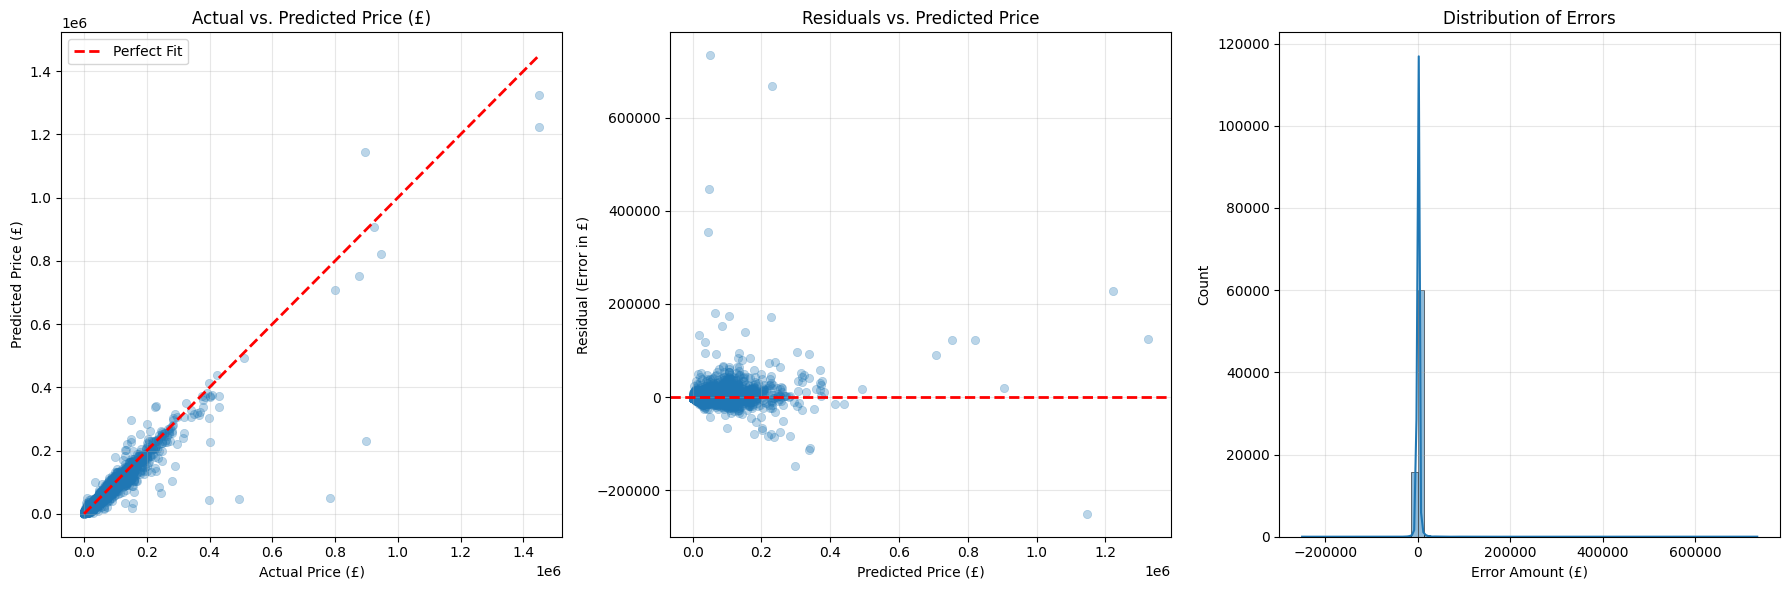

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get Predictions (Log Space)
print("Generating predictions...")
log_preds = model.predict(test_inputs, batch_size=512).flatten()

# 2. Convert to Real GBP (Inverse Log)
gbp_preds = np.expm1(log_preds) 

# 3. Calculate Residuals (Actual - Predicted)
residuals = test_targets_raw - gbp_preds

# --- PLOTTING ---
plt.figure(figsize=(18, 6))

# Plot A: Actual vs Predicted
plt.subplot(1, 3, 1)
sns.scatterplot(x=test_targets_raw, y=gbp_preds, alpha=0.3, edgecolor=None)
# Perfect fit line
min_val = min(test_targets_raw.min(), gbp_preds.min())
max_val = max(test_targets_raw.max(), gbp_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
plt.title("Actual vs. Predicted Price (£)")
plt.xlabel("Actual Price (£)")
plt.ylabel("Predicted Price (£)")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot B: Residuals vs Predicted
# Look for "fanning" (heteroscedasticity) or "U-shapes"
plt.subplot(1, 3, 2)
sns.scatterplot(x=gbp_preds, y=residuals, alpha=0.3, edgecolor=None) #, color='orange')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title("Residuals vs. Predicted Price")
plt.xlabel("Predicted Price (£)")
plt.ylabel("Residual (Error in £)")
plt.grid(True, alpha=0.3)

# Plot C: Error Distribution
# Should be a tall, thin bell curve centered at 0
plt.subplot(1, 3, 3)
sns.histplot(residuals, bins=71, kde=True)#, color='purple')
#plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.title("Distribution of Errors")
plt.xlabel("Error Amount (£)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Found Make Embedding Layer: embedding


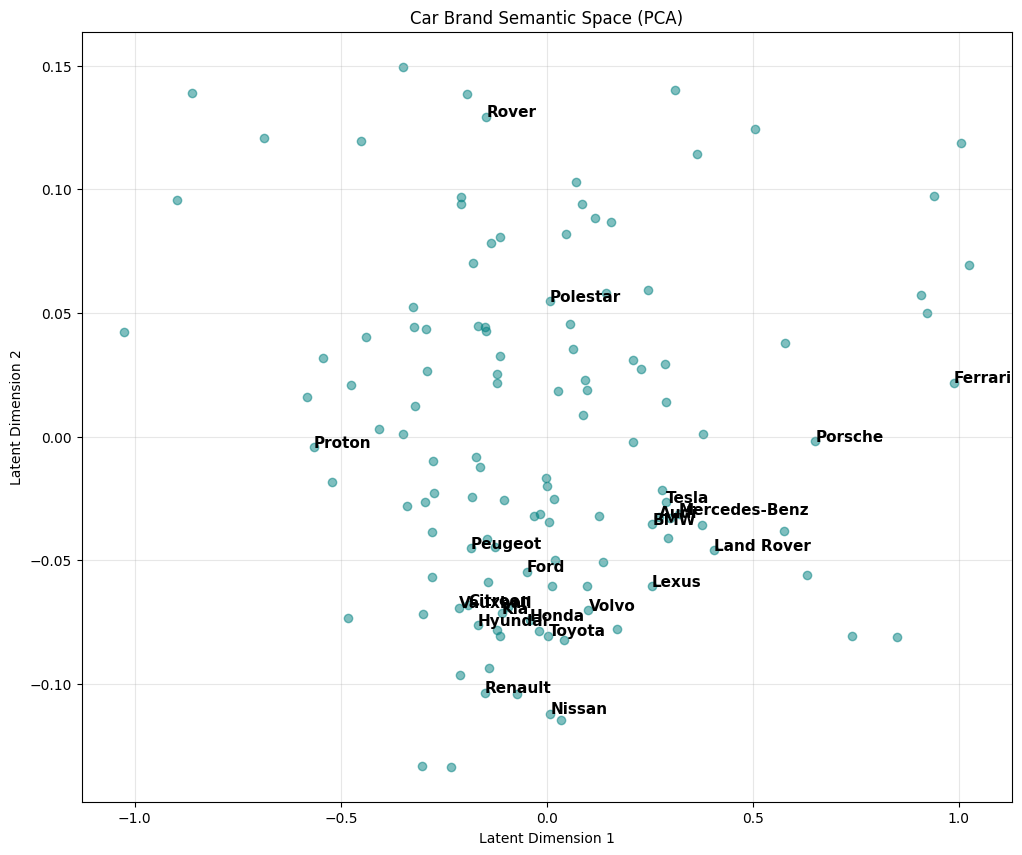

In [12]:
from sklearn.decomposition import PCA

# 1. Find the Make Embedding Layer
# We look for the layer connected to the 'make_in' input
target_layer = None
for layer in model.layers:
    # Check if this layer is an Embedding layer and its name contains 'embedding'
    # (Keras names them 'embedding_X' by default unless we named them explicitly)
    if isinstance(layer, layers.Embedding) and layer.output_dim == 10: 
        # We know Make dim is 10, Variant is 10, Model is 15, Fuel is 5.
        # This is a heuristic to find the right one.
        # Better yet, let's look at the config to be sure it's the right vocab size
        if layer.input_dim == len(make_vocab) + 1:
            target_layer = layer
            break

if target_layer:
    print(f"Found Make Embedding Layer: {target_layer.name}")
    weights = target_layer.get_weights()[0] # Shape: (Num_Makes + 1, 10)
    
    # 2. PCA Reduction (10D -> 2D)
    # Skip index 0 (UNK)
    visual_weights = weights[1:] 
    pca = PCA(n_components=2)
    coords = pca.fit_transform(visual_weights)

    # 3. Create Map (ID -> Name)
    id_to_make = {v: k for k, v in make_vocab.items()}

    # 4. Plot
    plt.figure(figsize=(12, 10))
    plt.scatter(coords[:, 0], coords[:, 1], alpha=0.5, c='teal')

    # Label points
    for i in range(len(coords)):
        make_name = id_to_make.get(i + 1, "Unknown")
        # Filter to only label popular brands to avoid messy text
        if make_name in ['Ford', 'BMW', 'Mercedes-Benz',   'Toyota', 'Audi', 'Hyundai', 'Renault', 'Citroen', 'Honda',
                         'Nissan', 'Vauxhall', 'Land Rover', 'Tesla', 'Porsche', 'Ferrari', 
                         'Kia',  'Peugeot', 'Proton', 'Rover', 'Polestar', 'Lexus', 'Volvo']:
            plt.annotate(make_name, (coords[i, 0], coords[i, 1]), fontsize=11, weight='bold')

    plt.title("Car Brand Semantic Space (PCA)")
    plt.xlabel("Latent Dimension 1")
    plt.ylabel("Latent Dimension 2")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Could not automatically find the Make embedding layer. Check layer names.")

In [13]:
train_df['make'].value_counts()

make
Mercedes-Benz    71710
Ford             49206
BMW              48829
Audi             43986
Volkswagen       42472
                 ...  
NG                   1
KTM                  1
Sunbeam              1
Alvis                1
Reo                  1
Name: count, Length: 126, dtype: int64

In [14]:
train_inputs[]

SyntaxError: invalid syntax (3420195352.py, line 1)